# Compressão de Imagens via Transformada de Wavelet (JPEG 2000)

Este notebook demonstra o funcionamento da transformada de Wavelet, do caso mais simples em sinais 1D até um pipeline de compressão de imagens no estilo do padrão JPEG 2000.

## 1. Imports e Configuração

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as img
import os
from dotenv import load_dotenv
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize

# Carregando variáveis de ambiente
load_dotenv()

# Configurações globais
img_size = (512, 512)

# Caminho carregado do arquivo .env
image_compression_path = os.getenv("IMAGE_COMPRESSION_PATH")

print(f"Imagem para a demonstração final: {image_compression_path}")
print(f"Tamanho das imagens: {img_size}")

## 2. A Ideia da Transformada: Médias e Detalhes

Um passo da transformada de Haar (a wavelet mais simples) separa um sinal em duas metades: as **médias** de cada par de vizinhos (a aproximação) e as **diferenças** de cada par (o detalhe). Em regiões suaves do sinal, as diferenças ficam próximas de zero.

In [ ]:
def haar_step(signal):
    evens = signal[0::2]
    odds = signal[1::2]

    # Médias (aproximação) e diferenças (detalhe) dos pares de vizinhos
    approximation = (evens + odds) / np.sqrt(2)
    detail = (evens - odds) / np.sqrt(2)

    return approximation, detail


def haar_step_inverse(approximation, detail):
    evens = (approximation + detail) / np.sqrt(2)
    odds = (approximation - detail) / np.sqrt(2)

    signal = np.zeros(len(evens) * 2)
    signal[0::2] = evens
    signal[1::2] = odds

    return signal

In [3]:
signal = np.array([4.0, 6.0, 10.0, 12.0, 8.0, 6.0, 5.0, 5.0])
approximation, detail = haar_step(signal)
reconstructed_signal = haar_step_inverse(approximation, detail)

print(f"Sinal original: {signal}")
print(f"Aproximação: {np.round(approximation, 4)}")
print(f"Detalhe: {np.round(detail, 4)}")
print(f"Sinal reconstruído: {reconstructed_signal}")

Sinal original: [ 4.  6. 10. 12.  8.  6.  5.  5.]
Aproximação: [ 7.0711 15.5563  9.8995  7.0711]
Detalhe: [-1.4142 -1.4142  1.4142  0.    ]
Sinal reconstruído: [ 4.  6. 10. 12.  8.  6.  5.  5.]


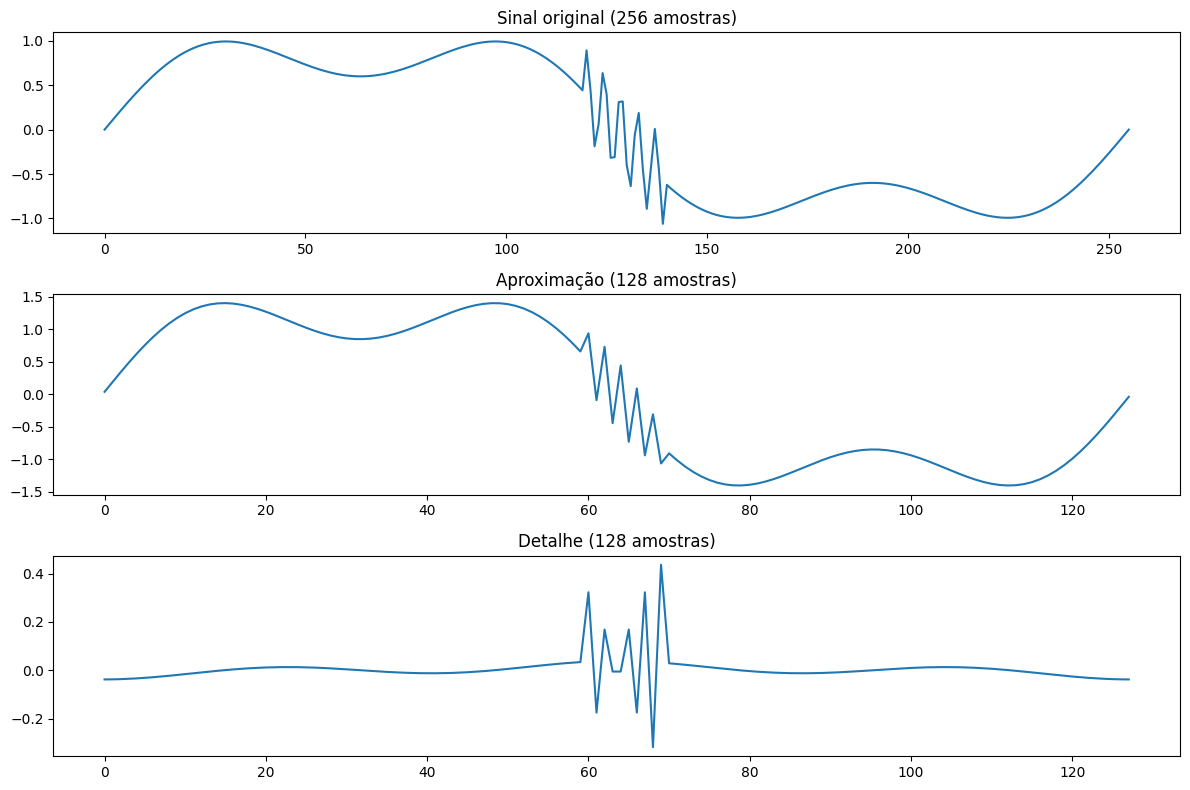

In [ ]:
t = np.linspace(0, 1, 256)
smooth_signal = np.sin(2 * np.pi * t) + 0.4 * np.sin(6 * np.pi * t)
smooth_signal[120:140] += 0.5 * np.sin(2 * np.pi * 60 * t[120:140])

approximation, detail = haar_step(smooth_signal)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(smooth_signal)
axes[0].set_title("Sinal original (256 amostras)")

axes[1].plot(approximation)
axes[1].set_title("Aproximação (128 amostras)")

axes[2].plot(detail)
axes[2].set_title("Detalhe (128 amostras)")

plt.tight_layout()
plt.show()

## 3. A Transformada como Álgebra Linear

Um passo de Haar é uma transformação linear, então podemos representá-lo por uma matriz $W$. Essa matriz é **ortogonal** ($W^T W = I$): a transformada é apenas uma mudança de base, e a inversa é simplesmente a transposta.

In [ ]:
def build_haar_matrix(n):
    W = np.zeros((n, n))

    for i in range(n // 2):
        # Linhas de média
        W[i, 2 * i] = 1 / np.sqrt(2)
        W[i, 2 * i + 1] = 1 / np.sqrt(2)

        # Linhas de diferença
        W[n // 2 + i, 2 * i] = 1 / np.sqrt(2)
        W[n // 2 + i, 2 * i + 1] = -1 / np.sqrt(2)

    return W

In [ ]:
W = build_haar_matrix(8)
print(f"Matriz de Haar 8x8:\n{np.round(W, 4)}\n")

# A multiplicação pela matriz é o passo da transformada
approximation, detail = haar_step(signal)
print(f"W @ sinal: {np.round(W @ signal, 4)}")
print(f"Aproximação e detalhe concatenados: {np.round(np.concatenate([approximation, detail]), 4)}")

# Como a matriz é ortogonal, a inversa é a transposta
print(f"\nW^T @ W é a identidade? {np.allclose(W.T @ W, np.eye(8))}")
print(f"Reconstrução com W^T: {W.T @ (W @ signal)}")

Matriz de Haar 8x8:
[[ 0.7071  0.7071  0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.7071  0.7071  0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.7071  0.7071  0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.7071  0.7071]
 [ 0.7071 -0.7071  0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.7071 -0.7071  0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.7071 -0.7071  0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.7071 -0.7071]]

W @ sinal: [ 7.0711 15.5563  9.8995  7.0711 -1.4142 -1.4142  1.4142  0.    ]
Aproximação e detalhe concatenados: [ 7.0711 15.5563  9.8995  7.0711 -1.4142 -1.4142  1.4142  0.    ]

W^T @ W é a identidade? True
Reconstrução com W^T: [ 4.  6. 10. 12.  8.  6.  5.  5.]


## 4. Decomposição Multinível

Podemos aplicar a transformada novamente sobre a aproximação, várias vezes. Isso gera a análise multirresolução: uma aproximação bem grosseira do sinal, junto dos detalhes de cada nível.

In [ ]:
def dwt(signal, levels, step):
    coefficients = []
    approximation = signal

    for _ in range(levels):
        approximation, detail = step(approximation)
        coefficients.append(detail)

    # Lista final na forma [aproximação, detalhe mais grosso, ..., detalhe mais fino]
    coefficients.append(approximation)
    coefficients.reverse()

    return coefficients


def idwt(coefficients, step_inverse):
    approximation = coefficients[0]

    for detail in coefficients[1:]:
        approximation = step_inverse(approximation, detail)

    return approximation

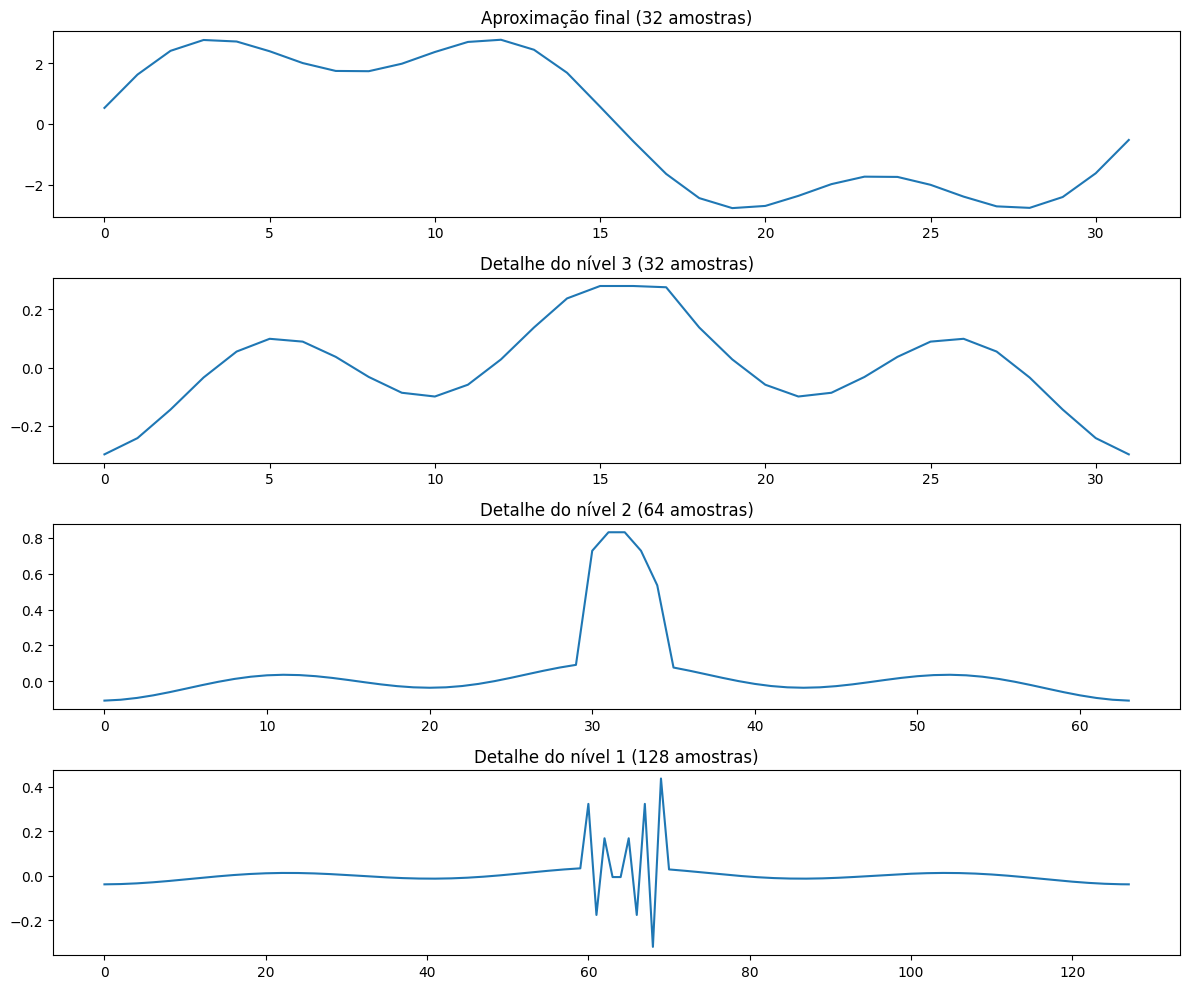

Reconstrução perfeita? True


In [8]:
levels = 3
coefficients = dwt(smooth_signal, levels, haar_step)
reconstructed_signal = idwt(coefficients, haar_step_inverse)

fig, axes = plt.subplots(levels + 1, 1, figsize=(12, 10))

axes[0].plot(coefficients[0])
axes[0].set_title(f"Aproximação final ({len(coefficients[0])} amostras)")

for i, detail in enumerate(coefficients[1:]):
    axes[i + 1].plot(detail)
    axes[i + 1].set_title(f"Detalhe do nível {levels - i} ({len(detail)} amostras)")

plt.tight_layout()
plt.show()

print(f"Reconstrução perfeita? {np.allclose(reconstructed_signal, smooth_signal)}")

## 5. A Transformada em Imagens (2D)

Para imagens, aplicamos a transformada 1D em todas as linhas e depois em todas as colunas. O resultado são 4 sub-bandas: **LL** (a aproximação), **HL** e **LH** (detalhes verticais e horizontais) e **HH** (detalhes diagonais). As funções recebem qual transformada 1D usar, o que será útil mais à frente.

In [ ]:
def dwt_step_2d(image, step):
    rows, cols = image.shape

    # Transformada nas linhas
    transformed = np.zeros((rows, cols))
    for i in range(rows):
        approximation, detail = step(image[i, :])
        transformed[i, :cols // 2] = approximation
        transformed[i, cols // 2:] = detail

    # Transformada nas colunas
    result = np.zeros((rows, cols))
    for j in range(cols):
        approximation, detail = step(transformed[:, j])
        result[:rows // 2, j] = approximation
        result[rows // 2:, j] = detail

    return result


def idwt_step_2d(transformed, step_inverse):
    rows, cols = transformed.shape

    # Inversa nas colunas
    image = np.zeros((rows, cols))
    for j in range(cols):
        image[:, j] = step_inverse(transformed[:rows // 2, j], transformed[rows // 2:, j])

    # Inversa nas linhas
    result = np.zeros((rows, cols))
    for i in range(rows):
        result[i, :] = step_inverse(image[i, :cols // 2], image[i, cols // 2:])

    return result

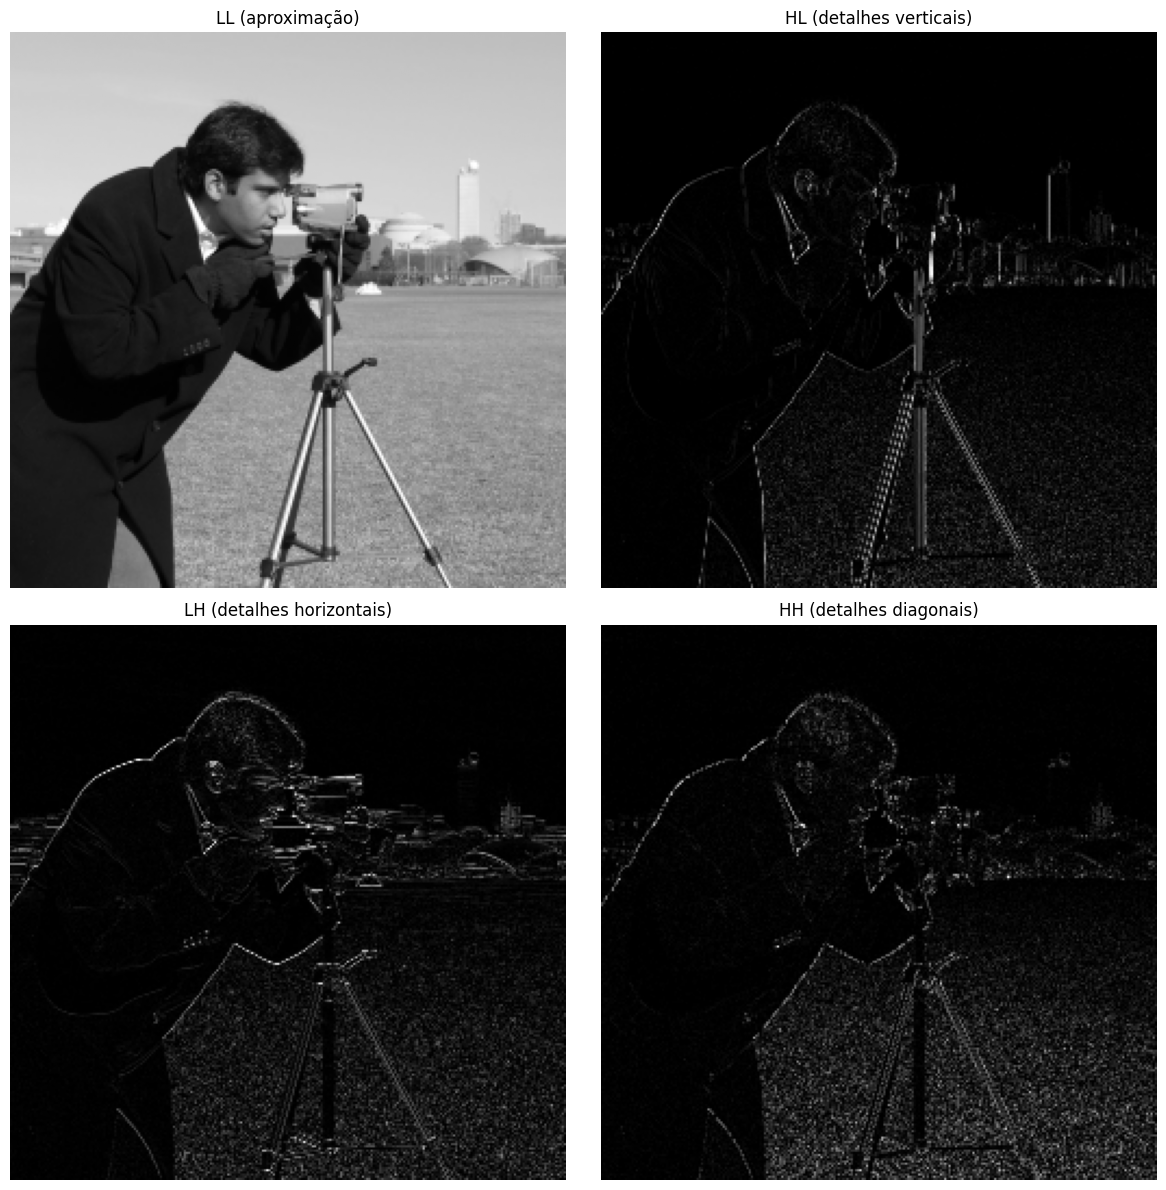

Reconstrução perfeita? True


In [10]:
# Imagem de teste clássica do scikit-image
image = data.camera() / 255.0
transformed = dwt_step_2d(image, haar_step)

rows, cols = transformed.shape
subbands = [
    (transformed[:rows // 2, :cols // 2], "LL (aproximação)"),
    (transformed[:rows // 2, cols // 2:], "HL (detalhes verticais)"),
    (transformed[rows // 2:, :cols // 2], "LH (detalhes horizontais)"),
    (transformed[rows // 2:, cols // 2:], "HH (detalhes diagonais)"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, (subband, title) in zip(axes.flat, subbands):
    ax.imshow(np.abs(subband), cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Reconstrução perfeita? {np.allclose(idwt_step_2d(transformed, haar_step_inverse), image)}")

## 6. Decomposição Multinível 2D

Assim como no caso 1D, aplicamos a transformada repetidamente sobre a sub-banda LL, formando a estrutura em pirâmide.

In [ ]:
def dwt2(image, levels, step):
    transformed = image.copy()
    rows, cols = image.shape

    for _ in range(levels):
        transformed[:rows, :cols] = dwt_step_2d(transformed[:rows, :cols], step)
        rows //= 2
        cols //= 2

    return transformed


def idwt2(transformed, levels, step_inverse):
    image = transformed.copy()
    rows = image.shape[0] // 2 ** (levels - 1)
    cols = image.shape[1] // 2 ** (levels - 1)

    for _ in range(levels):
        image[:rows, :cols] = idwt_step_2d(image[:rows, :cols], step_inverse)
        rows *= 2
        cols *= 2

    return image

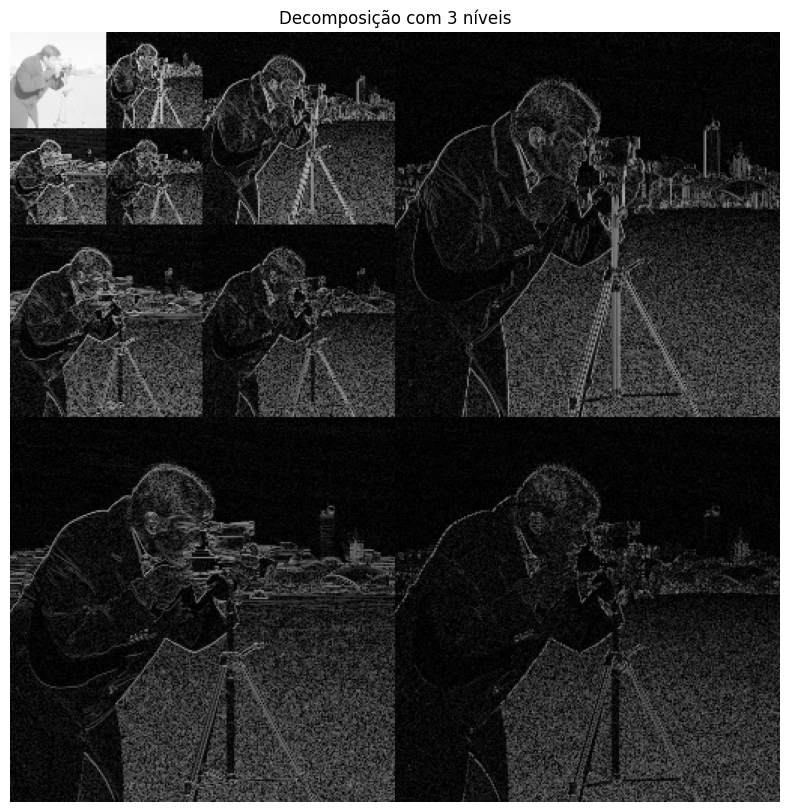

Reconstrução perfeita? True


In [ ]:
levels = 3
transformed = dwt2(image, levels, haar_step)

# Escala logarítmica só para conseguir enxergar os detalhes
plt.figure(figsize=(10, 10))
plt.imshow(np.log(np.abs(transformed) + 1e-2), cmap="gray")
plt.title(f"Decomposição com {levels} níveis")
plt.axis("off")
plt.show()

print(f"Reconstrução perfeita? {np.allclose(idwt2(transformed, levels, haar_step_inverse), image)}")

## 7. Compressão por Limiarização

A energia da imagem se concentra em pouquíssimos coeficientes, já que os detalhes são quase todos próximos de zero. Se zerarmos os menores coeficientes e guardarmos apenas os maiores, conseguimos reconstruir a imagem quase sem perda visível.

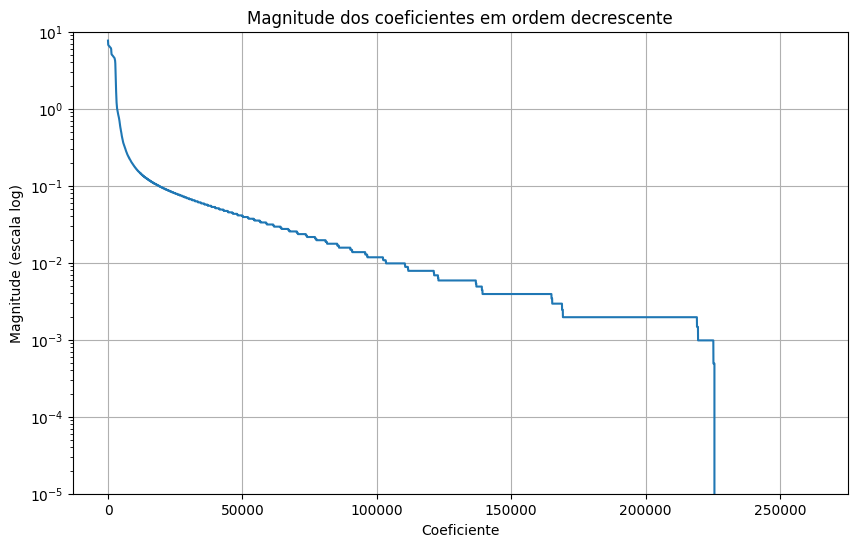

In [ ]:
# Ordem decrescente
magnitudes = np.sort(np.abs(transformed).flatten())[::-1]

plt.figure(figsize=(10, 6))
plt.semilogy(magnitudes)
plt.title("Magnitude dos coeficientes em ordem decrescente")
plt.xlabel("Coeficiente")
plt.ylabel("Magnitude (escala log)")
plt.ylim(1e-5, 10)
plt.grid(True)
plt.show()

In [ ]:
def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    return 10 * np.log10(1 / mse)


def compress_image(image, levels, keep_ratio, step, step_inverse):
    transformed = dwt2(image, levels, step)

    # Encontrando o limiar que mantém a fração desejada dos coeficientes
    coefficients = np.sort(np.abs(transformed).flatten())
    threshold = coefficients[int((1 - keep_ratio) * len(coefficients))]

    compressed = transformed * (np.abs(transformed) >= threshold)

    reconstructed = idwt2(compressed, levels, step_inverse)
    return reconstructed

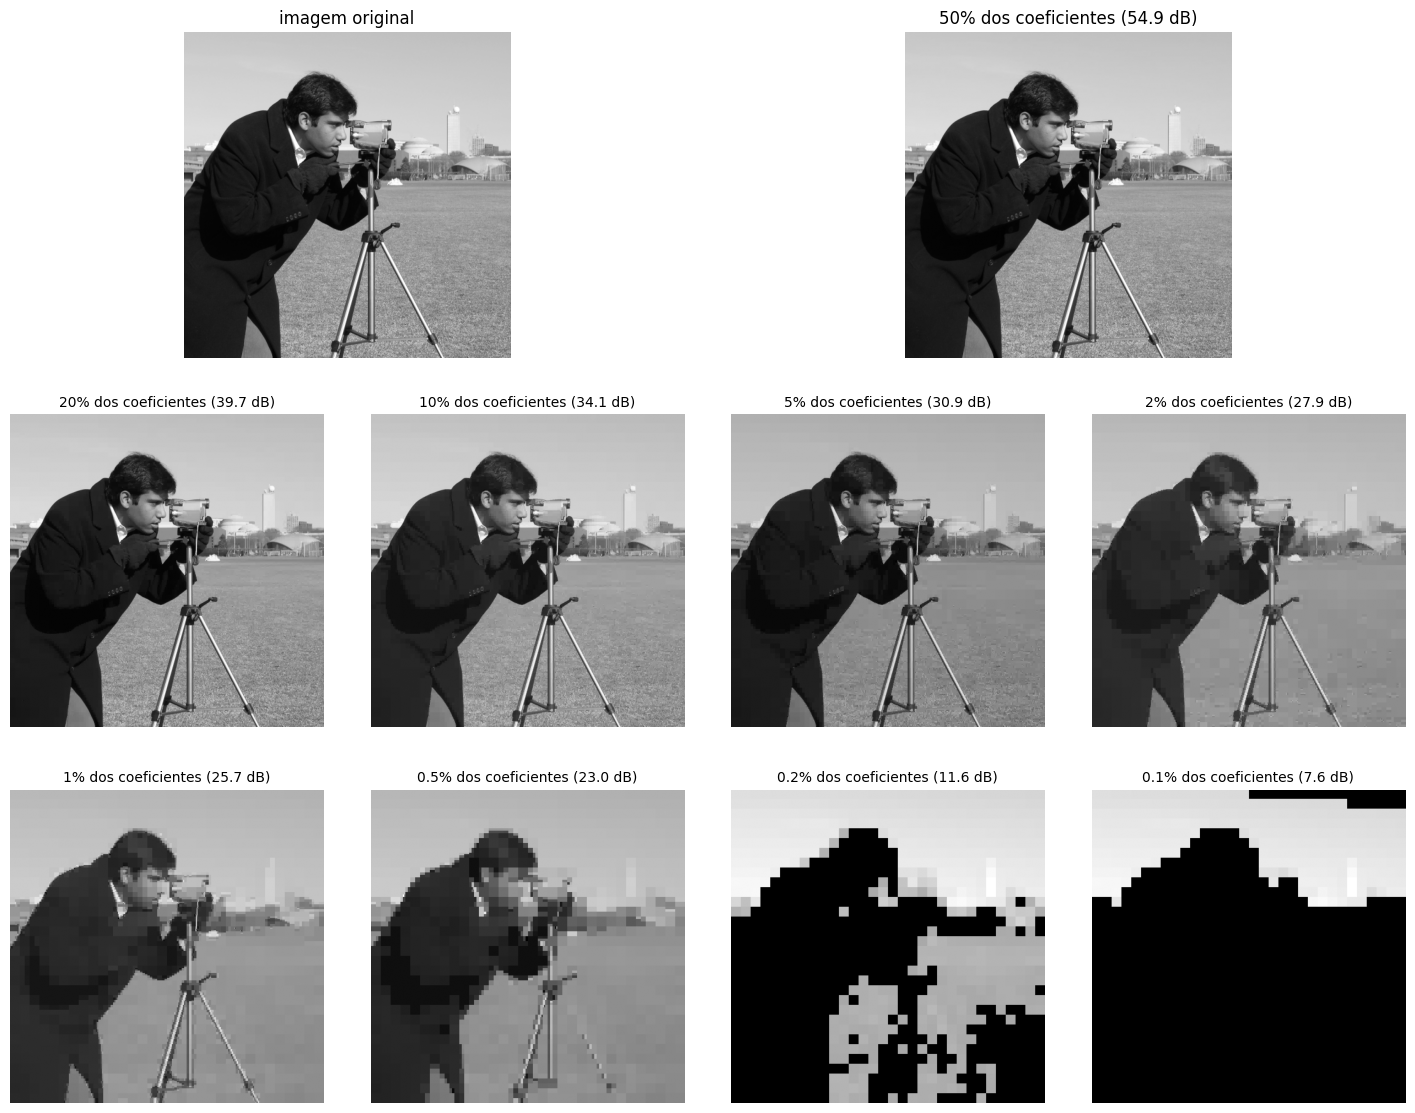

In [ ]:
levels = 4

keep_ratios = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]

reconstructed_images = []
for keep_ratio in keep_ratios:
    reconstructed = compress_image(image, levels, keep_ratio, haar_step, haar_step_inverse)
    reconstructed_images.append(reconstructed)

# Original e melhor caso no topo, os demais embaixo (2 linhas de 4)
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 4, hspace=0.15, wspace=0.15)

ax_original = fig.add_subplot(gs[0, :2])
ax_original.imshow(image, cmap="gray")
ax_original.set_title("imagem original", fontsize=12)
ax_original.axis("off")

ax_best = fig.add_subplot(gs[0, 2:])
ax_best.imshow(reconstructed_images[0], cmap="gray")
ax_best.set_title(f"{keep_ratios[0]*100:g}% dos coeficientes ({psnr(image, reconstructed_images[0]):.1f} dB)", fontsize=12)
ax_best.axis("off")

for i in range(8):
    row = 1 + (i // 4)
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(reconstructed_images[i + 1], cmap="gray")
    ax.set_title(f"{keep_ratios[i + 1]*100:g}% dos coeficientes ({psnr(image, reconstructed_images[i + 1]):.1f} dB)", fontsize=10)
    ax.axis("off")

plt.show()

## 8. A Wavelet do JPEG 2000: CDF 9/7 e o Esquema Lifting

A Haar é ótima para entender o processo, mas gera artefatos "quadrados". O JPEG 2000 usa a wavelet biortogonal CDF 9/7, calculada pelo esquema *lifting*: as amostras ímpares são preditas pelas pares vizinhas (sobrando como detalhe apenas o erro dessa predição), e as pares são atualizadas para manter a média do sinal estável. Como cada passo é invertível, a reconstrução continua exata.

In [ ]:
# Coeficientes de lifting da CDF 9/7
ALPHA = -1.586134342
BETA = -0.05298011854
GAMMA = 0.8829110762
DELTA = 0.4435068522
ZETA = 1.149604398


def cdf97_step(signal):
    evens = signal[0::2].copy()
    odds = signal[1::2].copy()

    # Predição 1 e atualização 1 (as bordas são espelhadas)
    odds += ALPHA * (evens + np.append(evens[1:], evens[-1]))
    evens += BETA * (odds + np.insert(odds[:-1], 0, odds[0]))

    # Predição 2 e atualização 2
    odds += GAMMA * (evens + np.append(evens[1:], evens[-1]))
    evens += DELTA * (odds + np.insert(odds[:-1], 0, odds[0]))

    # Escala final
    approximation = ZETA * evens
    detail = odds / ZETA

    return approximation, detail


def cdf97_step_inverse(approximation, detail):
    evens = approximation / ZETA
    odds = detail * ZETA

    evens -= DELTA * (odds + np.insert(odds[:-1], 0, odds[0]))
    odds -= GAMMA * (evens + np.append(evens[1:], evens[-1]))
    evens -= BETA * (odds + np.insert(odds[:-1], 0, odds[0]))
    odds -= ALPHA * (evens + np.append(evens[1:], evens[-1]))

    signal = np.zeros(len(evens) * 2)
    signal[0::2] = evens
    signal[1::2] = odds

    return signal

In [ ]:
test_signal = np.random.rand(64)
approximation, detail = cdf97_step(test_signal)
print(f"Reconstrução perfeita? {np.allclose(cdf97_step_inverse(approximation, detail), test_signal)}")

Reconstrução perfeita? True


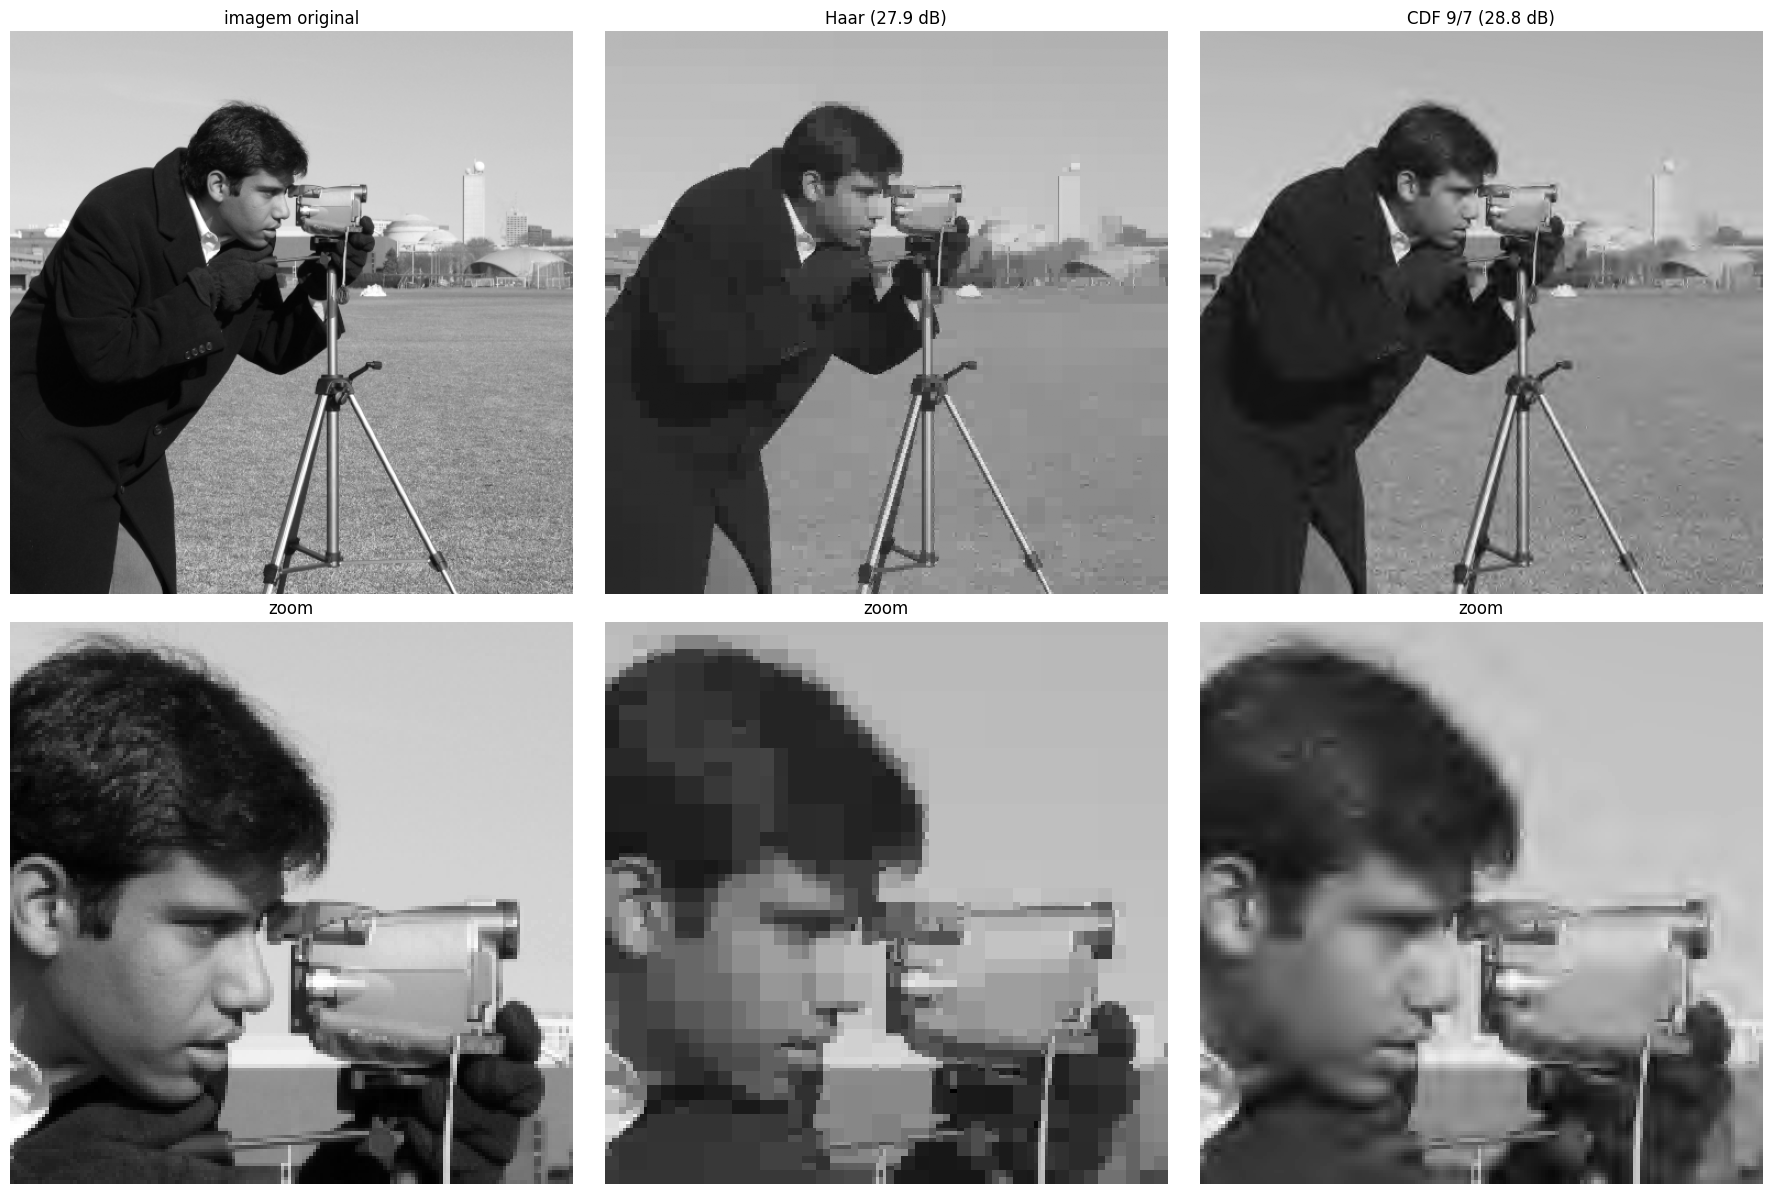

In [ ]:
keep_ratio = 0.02
reconstructed_haar = compress_image(image, levels, keep_ratio, haar_step, haar_step_inverse)
reconstructed_cdf = compress_image(image, levels, keep_ratio, cdf97_step, cdf97_step_inverse)

# Recorte para enxergar os artefatos de perto
zoom = (slice(60, 220), slice(180, 340))

images_compare = [
    (image, "imagem original"),
    (reconstructed_haar, f"Haar ({psnr(image, reconstructed_haar):.1f} dB)"),
    (reconstructed_cdf, f"CDF 9/7 ({psnr(image, reconstructed_cdf):.1f} dB)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for j, (compare_image, title) in enumerate(images_compare):
    axes[0, j].imshow(compare_image, cmap="gray")
    axes[0, j].set_title(title)
    axes[0, j].axis("off")

    axes[1, j].imshow(compare_image[zoom], cmap="gray")
    axes[1, j].set_title("zoom")
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()

## 9. Pipeline JPEG 2000 Simplificado

O JPEG 2000 completo segue a sequência: divisão em *tiles* → *DC level shift* → DWT com a CDF 9/7 → quantização por sub-banda → codificação de entropia (EBCOT). Implementação de uma versão simplificada dessa sequência, trocando o EBCOT por uma estimativa de tamanho baseada na entropia dos coeficientes quantizados.

In [ ]:
def quantize(transformed, levels, base_step):
    rows, cols = transformed.shape
    quantized = np.zeros((rows, cols), dtype=int)

    # Sub-banda LL usa o passo base
    ll_rows, ll_cols = rows // 2 ** levels, cols // 2 ** levels
    quantized[:ll_rows, :ll_cols] = np.round(transformed[:ll_rows, :ll_cols] / base_step)

    # Sub-bandas de detalhe, do nível mais grosso ao mais fino
    for level in range(levels, 0, -1):
        step = base_step * 2 ** (levels - level)
        r, c = rows // 2 ** level, cols // 2 ** level

        quantized[:r, c:2 * c] = np.round(transformed[:r, c:2 * c] / step)
        quantized[r:2 * r, :c] = np.round(transformed[r:2 * r, :c] / step)
        quantized[r:2 * r, c:2 * c] = np.round(transformed[r:2 * r, c:2 * c] / step)

    return quantized


def dequantize(quantized, levels, base_step):
    rows, cols = quantized.shape
    transformed = np.zeros((rows, cols))

    ll_rows, ll_cols = rows // 2 ** levels, cols // 2 ** levels
    transformed[:ll_rows, :ll_cols] = quantized[:ll_rows, :ll_cols] * base_step

    for level in range(levels, 0, -1):
        step = base_step * 2 ** (levels - level)
        r, c = rows // 2 ** level, cols // 2 ** level

        transformed[:r, c:2 * c] = quantized[:r, c:2 * c] * step
        transformed[r:2 * r, :c] = quantized[r:2 * r, :c] * step
        transformed[r:2 * r, c:2 * c] = quantized[r:2 * r, c:2 * c] * step

    return transformed


def estimate_size(quantized):
    values, counts = np.unique(quantized, return_counts=True)
    probabilities = counts / counts.sum()
    entropy = -np.sum(probabilities * np.log2(probabilities))

    return entropy * quantized.size / 8


def jpeg2000_compress(image, levels, base_step, step, step_inverse):
    # DC level shift
    shifted = image - 0.5

    transformed = dwt2(shifted, levels, step)
    quantized = quantize(transformed, levels, base_step)

    # O tamanho que o EBCOT alcançaria, estimado pela entropia
    size = estimate_size(quantized)

    # Reconstruindo a imagem a partir dos coeficientes quantizados
    reconstructed = idwt2(dequantize(quantized, levels, base_step), levels, step_inverse) + 0.5

    return reconstructed, size

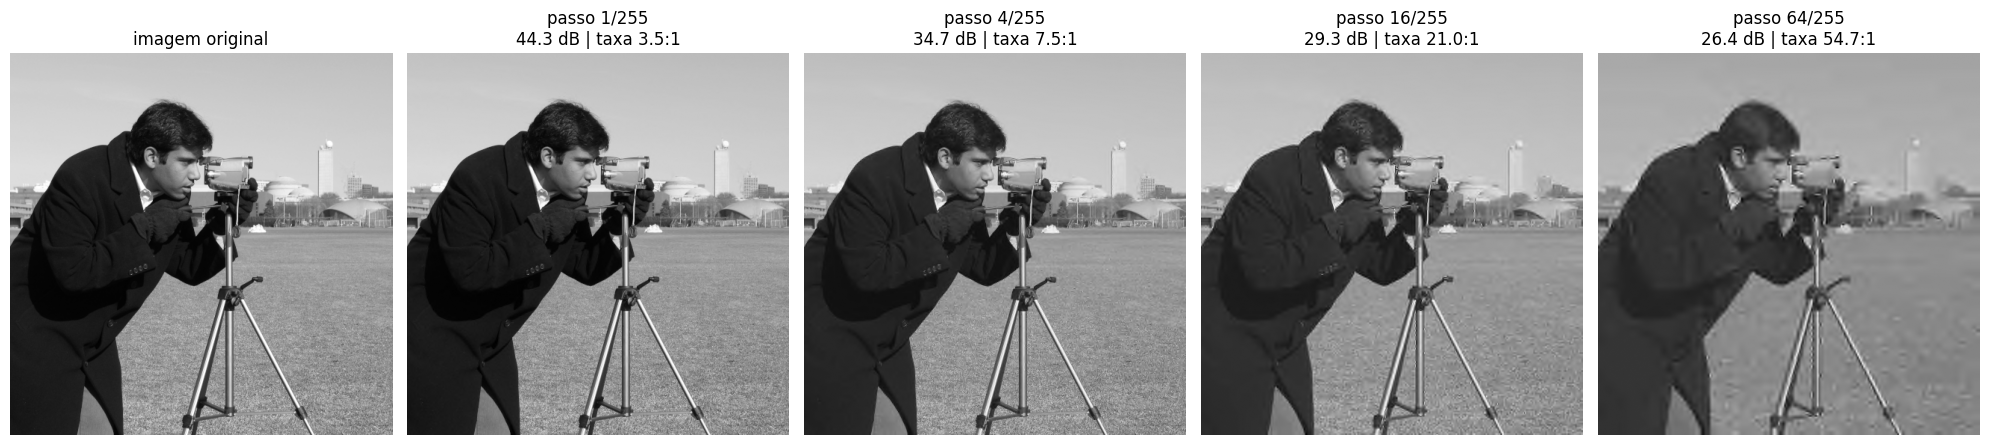

In [ ]:
base_steps = [1 / 255, 4 / 255, 16 / 255, 64 / 255]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("imagem original")
axes[0].axis("off")

for i, base_step in enumerate(base_steps):
    reconstructed, size = jpeg2000_compress(image, levels, base_step, cdf97_step, cdf97_step_inverse)
    ratio = image.size / size

    axes[i + 1].imshow(reconstructed, cmap="gray")
    axes[i + 1].set_title(f"passo {base_step*255:g}/255\n{psnr(image, reconstructed):.1f} dB | taxa {ratio:.1f}:1")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

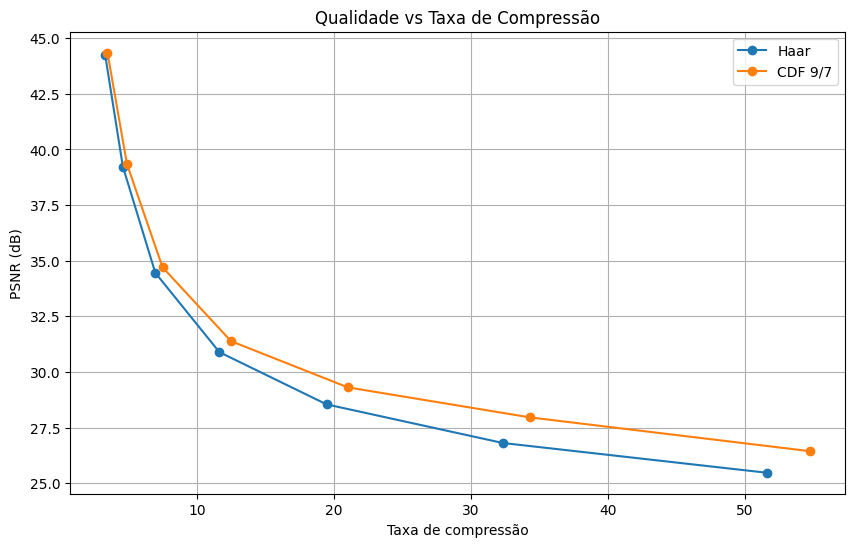

In [ ]:
base_steps = np.array([1, 2, 4, 8, 16, 32, 64]) / 255

wavelets = [
    ("Haar", haar_step, haar_step_inverse),
    ("CDF 9/7", cdf97_step, cdf97_step_inverse),
]

plt.figure(figsize=(10, 6))

for name, step, step_inverse in wavelets:
    ratios = []
    psnrs = []

    for base_step in base_steps:
        reconstructed, size = jpeg2000_compress(image, levels, base_step, step, step_inverse)
        ratios.append(image.size / size)
        psnrs.append(psnr(image, reconstructed))

    plt.plot(ratios, psnrs, marker="o", label=name)

plt.title("Qualidade vs Taxa de Compressão")
plt.xlabel("Taxa de compressão")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.legend()
plt.show()

## 10. Demonstração Final

Aplicando o pipeline completo em uma foto real (configurada no arquivo `.env`), com vários níveis de qualidade.

In [ ]:
def _process_final_compression(path_image, levels, base_steps):
    new_image = img.imread(path_image)

    # Convertendo a imagem para escala de cinza
    if new_image.ndim == 3:
        new_image = rgb2gray(new_image)

    # Redimensionando a imagem
    new_image = resize(new_image, img_size, anti_aliasing=True)

    results = []
    for base_step in base_steps:
        reconstructed, size = jpeg2000_compress(new_image, levels, base_step, cdf97_step, cdf97_step_inverse)
        results.append((reconstructed, psnr(new_image, reconstructed), new_image.size / size))

    return new_image, results

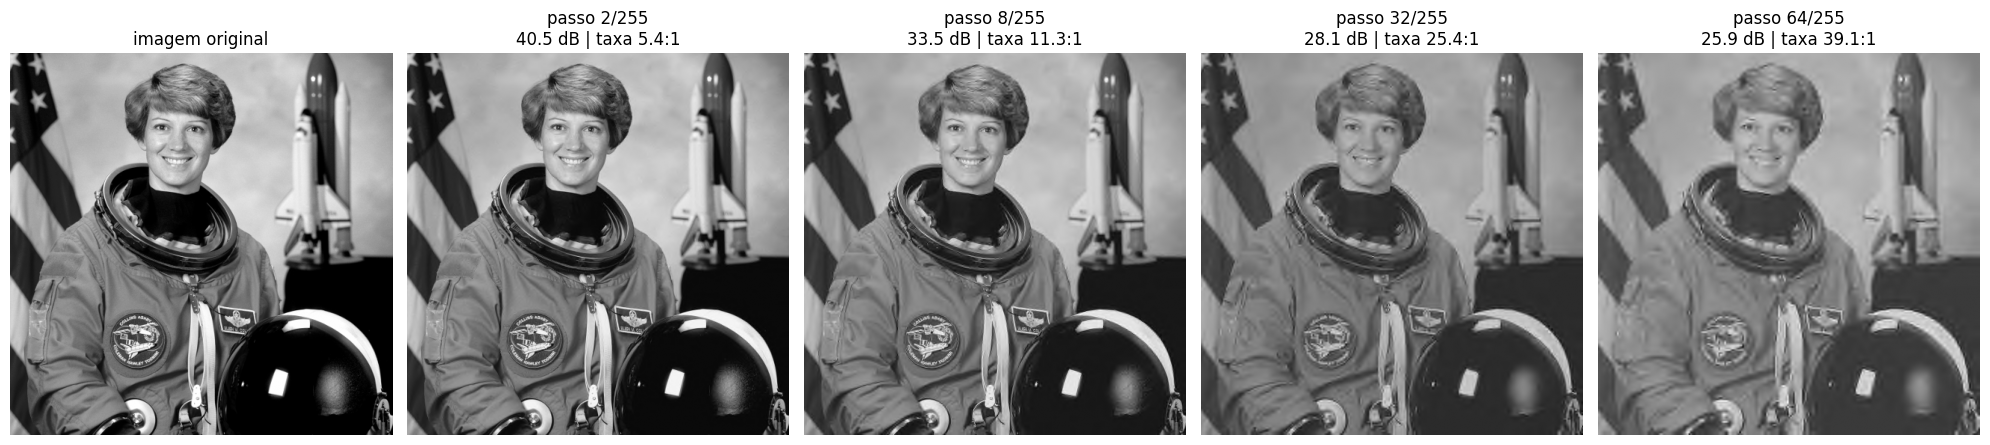

In [23]:
base_steps = [2 / 255, 8 / 255, 32 / 255, 64 / 255]
new_image, results = _process_final_compression(image_compression_path, levels, base_steps)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(new_image, cmap="gray")
axes[0].set_title("imagem original")
axes[0].axis("off")

for i, (reconstructed, quality, ratio) in enumerate(results):
    axes[i + 1].imshow(reconstructed, cmap="gray")
    axes[i + 1].set_title(f"passo {base_steps[i]*255:g}/255\n{quality:.1f} dB | taxa {ratio:.1f}:1")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()